In [1]:
import requests
import pandas as pd

In [2]:
url = "https://odre.opendatasoft.com/api/explore/v2.1/catalog/datasets/eco2mix-national-tr/records"
params = {
    "limit": 100,
    "order_by": "date_heure desc",
    "where": "consommation IS NOT NULL",
}
response = requests.get(url, params=params, timeout=10)
response.status_code

200

In [3]:
{
  "total_count": 6496,
  "results": [
    {"date_heure": "2026-09-06T13:45:00+00:00", "consommation": 41416},
    {"date_heure": "2026-09-06T13:30:00+00:00", "consommation": 42026}
  ]
}

{'total_count': 6496,
 'results': [{'date_heure': '2026-09-06T13:45:00+00:00',
   'consommation': 41416},
  {'date_heure': '2026-09-06T13:30:00+00:00', 'consommation': 42026}]}

In [4]:
data = response.json()

In [5]:
df = pd.DataFrame(data["results"])

In [6]:
export_url = "https://odre.opendatasoft.com/api/explore/v2.1/catalog/datasets/eco2mix-national-tr/exports/json"
params = {"where": "consommation IS NOT NULL", "order_by": "date_heure asc"}
response = requests.get(export_url, params=params, timeout=30)
data = response.json()
df = pd.DataFrame(data)
df.shape

(7276, 41)

In [7]:
df.head()

,perimetre,nature,date,heure,date_heure,consommation,prevision_j1,prevision_j,fioul,charbon,...,gaz_ccg,gaz_autres,hydraulique_fil_eau_eclusee,hydraulique_lacs,hydraulique_step_turbinage,bioenergies_dechets,bioenergies_biomasse,bioenergies_biogaz,stockage_batterie,destockage_batterie
0,France,Données temps réel,2026-07-01,00:00,2026-06-30T22:00:00+00:00,46807,47000,47000,35,0,...,4783,0,3614,2255,2100,398,318,301,-236,8
1,France,Données temps réel,2026-07-01,00:15,2026-06-30T22:15:00+00:00,46358,46100,46100,36,0,...,4438,0,3730,1955,2124,399,320,301,-21,9
2,France,Données temps réel,2026-07-01,00:30,2026-06-30T22:30:00+00:00,45014,45200,45200,36,0,...,4054,0,3687,1887,1321,401,319,301,-19,8
3,France,Données temps réel,2026-07-01,00:45,2026-06-30T22:45:00+00:00,43599,44200,44200,36,0,...,3846,0,3664,1489,897,399,319,301,-22,8
4,France,Données temps réel,2026-07-01,01:00,2026-06-30T23:00:00+00:00,43059,43200,43200,36,0,...,3668,0,3739,1431,814,398,319,301,-62,8


In [40]:
from pathlib import Path

output_dir = Path("../data/raw")
output_dir.mkdir(parents=True, exist_ok=True)
output_file = output_dir / "eco2mix_historical.csv"
df.to_csv(output_file, index=False)
print(f"Saved to: {output_file.resolve()}")

Saved to: /Users/damsonquy/Desktop/MLE Projects/ml-monitoring-pipeline/data/raw/eco2mix_historical.csv


In [41]:
df['date_heure'] = pd.to_datetime(df['date_heure'])

In [42]:
df.dtypes

perimetre                                   object
nature                                      object
date                                        object
heure                                       object
date_heure                     datetime64[ns, UTC]
consommation                                 int64
prevision_j1                                 int64
prevision_j                                  int64
fioul                                        int64
charbon                                      int64
gaz                                          int64
nucleaire                                    int64
eolien                                       int64
eolien_terrestre                             int64
eolien_offshore                              int64
solaire                                      int64
hydraulique                                  int64
pompage                                      int64
bioenergies                                  int64
ech_physiques                  

In [43]:
df['date_heure'].is_monotonic_increasing

True

In [44]:
df['date_heure'].duplicated().sum()

np.int64(0)

In [45]:
df['date_heure'].diff()

0                  NaT
1      0 days 00:15:00
2      0 days 00:15:00
3      0 days 00:15:00
4      0 days 00:15:00
             ...      
7271   0 days 00:15:00
7272   0 days 00:15:00
7273   0 days 00:15:00
7274   0 days 00:15:00
7275   0 days 00:15:00
Name: date_heure, Length: 7276, dtype: timedelta64[ns]

In [46]:
df.isnull().sum()

perimetre                      0
nature                         0
date                           0
heure                          0
date_heure                     0
consommation                   0
prevision_j1                   0
prevision_j                    0
fioul                          0
charbon                        0
gaz                            0
nucleaire                      0
eolien                         0
eolien_terrestre               0
eolien_offshore                0
solaire                        0
hydraulique                    0
pompage                        0
bioenergies                    0
ech_physiques                  0
taux_co2                       0
ech_comm_angleterre            0
ech_comm_espagne               0
ech_comm_italie                0
ech_comm_suisse                0
ech_comm_allemagne_belgique    0
fioul_tac                      0
fioul_cogen                    0
fioul_autres                   0
gaz_tac                        0
gaz_cogen 

In [47]:
df['consommation'].describe()

count     7276.000000
mean     43565.280099
std       5652.483662
min      30287.000000
25%      39160.000000
50%      43913.000000
75%      47995.250000
max      56887.000000
Name: consommation, dtype: float64

In [48]:
df_subset = df[["date_heure", "consommation", "prevision_j", "prevision_j1"]].copy()
df_subset.head()

,date_heure,consommation,prevision_j,prevision_j1
0,2026-06-30 22:00:00+00:00,46807,47000,47000
1,2026-06-30 22:15:00+00:00,46358,46100,46100
2,2026-06-30 22:30:00+00:00,45014,45200,45200
3,2026-06-30 22:45:00+00:00,43599,44200,44200
4,2026-06-30 23:00:00+00:00,43059,43200,43200


In [49]:
gaps = df['date_heure'].diff().dropna()
(gaps != pd.Timedelta(minutes=15)).sum()

np.int64(0)

<Axes: xlabel='date_heure'>

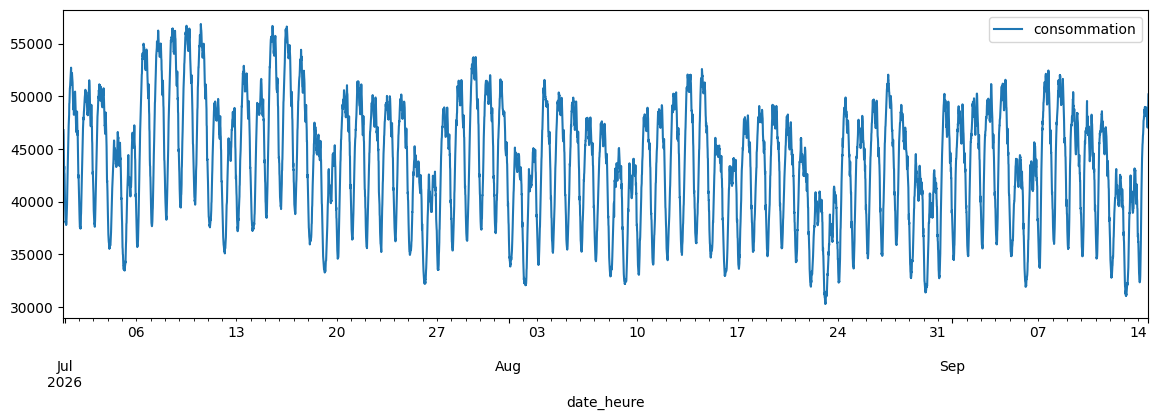

In [50]:
import matplotlib.pyplot as plt
df.plot(x='date_heure', y='consommation', figsize=(14, 4))

In [51]:
df_features = df_subset.copy()
df_features['target'] = df_features['consommation'].shift(-1)

In [52]:
df_features[['date_heure', 'consommation', 'target']].head(3)

,date_heure,consommation,target
0,2026-06-30 22:00:00+00:00,46807,46358.0
1,2026-06-30 22:15:00+00:00,46358,45014.0
2,2026-06-30 22:30:00+00:00,45014,43599.0


In [53]:
for lag in [1, 4, 96, 672]:
    df_features[f'lag_{lag}'] = df_features['consommation'].shift(lag)

In [54]:
df_features['roll_mean_4'] = df_features['consommation'].rolling(4).mean()
df_features['roll_std_4'] = df_features['consommation'].rolling(4).std()
df_features['roll_mean_96'] = df_features['consommation'].rolling(96).mean()

In [55]:
df_features['hour'] = df_features['date_heure'].dt.hour
df_features['day_of_week'] = df_features['date_heure'].dt.dayofweek
df_features['is_weekend'] = df_features['day_of_week'].isin([5, 6]).astype(int)
df_features['month'] = df_features['date_heure'].dt.month

In [56]:
before = df_features.shape[0]
df_features = df_features.dropna()
after = df_features.shape[0]
before, after

(7276, 6603)

In [57]:
feature_cols = ['consommation', 'lag_1', 'lag_4', 'lag_96', 'lag_672',
                    'roll_mean_4', 'roll_std_4', 'roll_mean_96',
                    'hour', 'day_of_week', 'is_weekend', 'month']
X = df_features[feature_cols]
y = df_features['target']

In [58]:
split_idx = int(len(X) * 0.85)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

In [59]:
df_features['date_heure'].iloc[[0, split_idx-1, split_idx, -1]]

672    2026-07-07 22:00:00+00:00
6283   2026-09-04 08:45:00+00:00
6284   2026-09-04 09:00:00+00:00
7274   2026-09-14 16:30:00+00:00
Name: date_heure, dtype: datetime64[ns, UTC]

In [60]:
import xgboost
xgboost.__version__

'2.1.4'

In [61]:
import xgboost as xgb
model = xgb.XGBRegressor(n_estimators=200, max_depth=4, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [62]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
mae, rmse

(296.8851814770434, 387.1537535081183)

In [63]:
baseline = df_features['prevision_j'].iloc[split_idx:]
baseline_mae = mean_absolute_error(y_test, baseline)
baseline_mae

708.3027245206862

In [64]:
persistence_pred = X_test['consommation']
persistence_mae = mean_absolute_error(y_test, persistence_pred)
persistence_mae

437.99192734611506

In [65]:
train_pred = model.predict(X_train)
train_mae = mean_absolute_error(y_train, train_pred)
train_mae

159.89320874910905

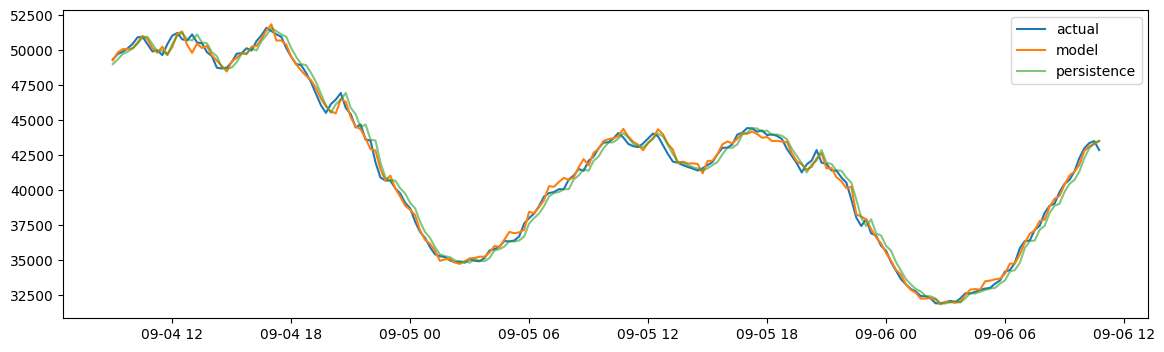

In [66]:
plot_df = df_features.iloc[split_idx:split_idx+200]
plt.figure(figsize=(14, 4))
plt.plot(plot_df['date_heure'], y_test.iloc[:200], label='actual')
plt.plot(plot_df['date_heure'], y_pred[:200], label='model')
plt.plot(plot_df['date_heure'], persistence_pred.iloc[:200], label='persistence', alpha=0.6)
plt.legend()

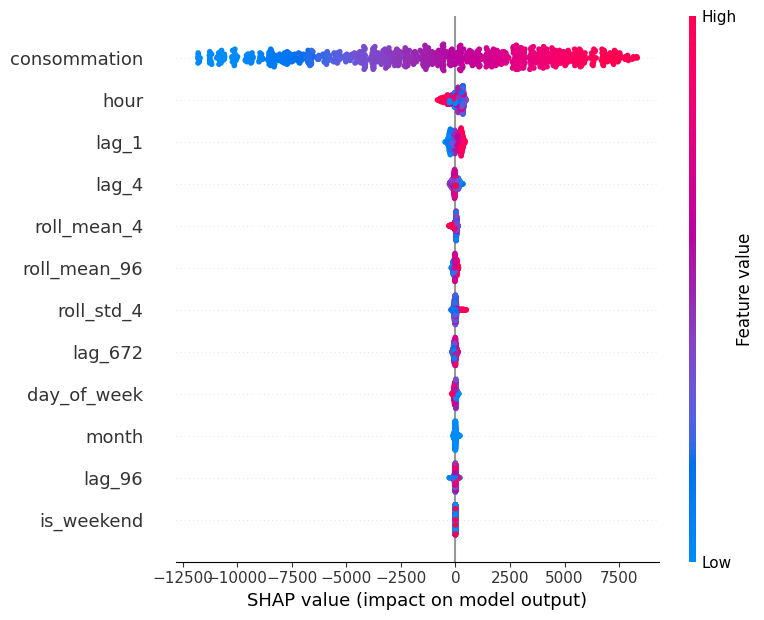

In [67]:
import shap
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)
shap.summary_plot(shap_values, X_test)

In [68]:
from pathlib import Path
model_dir = Path("../models")
model_dir.mkdir(parents=True, exist_ok=True)
model.save_model(model_dir / "xgb_v1.json")